## Poisson Equation

In [`05_laplace_petsc.ipynb`](05_laplace_petsc.ipynb) we solved the steady-state Laplace equation — a homogeneous problem driven entirely by its boundary conditions. Here we move to **Step 10 of the [12 Steps to Navier-Stokes](http://lorenabarba.com/blog/cfd-python-12-steps-to-navier-stokes/)** series and add a source term, turning the Laplace equation into the Poisson equation:

$$\frac{\partial^2 p}{\partial x^2} + \frac{\partial^2 p}{\partial y^2} = b$$

The source term $b$ is concentrated at two interior points:

$$b_{i,j} = 100 \quad \text{at}\quad i = n_x/4,\ j = n_y/4$$
$$b_{i,j} = -100 \quad \text{at}\quad i = 3n_x/4,\ j = 3n_y/4$$
$$b_{i,j} = 0 \quad \text{everywhere else}$$

Boundary conditions are homogeneous Dirichlet: $p = 0$ on all four edges.

As in the Laplace example, we use **PETSc** to solve the resulting linear problem in a single step. Devito generates a residual function and a **matrix-free Jacobian** routine that is passed to PETSc's KSP solver — the Jacobian is applied on-the-fly via the generated stencil kernel, without ever being assembled into a matrix.

## Environment setup

PETSc paths must be set before importing Devito.

In [1]:
import os

os.environ['PETSC_DIR'] = '/home/zl5621/petsc'
os.environ['PETSC_ARCH'] = 'zoe-petsc-section'
os.environ['CC'] = 'mpicc'

## Imports and Devito configuration

In [2]:
import numpy as np
%matplotlib inline

from devito import (Grid, Function, Eq, Operator, switchconfig,
                    configuration, SubDomain)
from devito.petsc import petscsolve, EssentialBC
from devito.petsc.initialize import PetscInitialize
from examples.cfd import plot_field

configuration['compiler'] = 'custom'

PetscInitialize()

Operator `kernel_init` ran in 0.06 s


## Boundary subdomains

PETSc essential (Dirichlet) boundary conditions are imposed via `EssentialBC`, which requires a `SubDomain` covering each boundary edge. We define four thin subdomains — one cell deep — for the top, bottom, left and right edges. The top and bottom subdomains span the full width including corners; the left and right subdomains cover the interior rows of their respective edges.

In [3]:
class SubTop(SubDomain):
    name = 'subtop'

    def define(self, dimensions):
        x, y = dimensions
        return {x: x, y: ('right', 1)}


class SubBottom(SubDomain):
    name = 'subbottom'

    def define(self, dimensions):
        x, y = dimensions
        return {x: x, y: ('left', 1)}


class SubLeft(SubDomain):
    name = 'subleft'

    def define(self, dimensions):
        x, y = dimensions
        return {x: ('left', 1), y: ('middle', 1, 1)}


class SubRight(SubDomain):
    name = 'subright'

    def define(self, dimensions):
        x, y = dimensions
        return {x: ('right', 1), y: ('middle', 1, 1)}


sub1 = SubTop()
sub2 = SubBottom()
sub3 = SubLeft()
sub4 = SubRight()

subdomains = (sub1, sub2, sub3, sub4)

## Problem setup

We use a $50 \times 50$ grid on the domain $[0, 2] \times [0, 1]$. The source term $b$ is stored in a time-constant `Function` with two non-zero entries: a positive source at one-quarter of the domain and a negative sink at three-quarters. The boundary function `bc_zero` holds the homogeneous Dirichlet data ($p = 0$ on all edges).

In [4]:
nx = 50
ny = 50
xmax = 2.
ymax = 1.

grid = Grid(
    shape=(nx, ny), extent=(xmax, ymax),
    subdomains=subdomains, dtype=np.float64
)

# Pressure field (unknown)
p = Function(name='p', grid=grid, space_order=2, dtype=np.float64)

# Source term
b = Function(name='b', grid=grid, space_order=2, dtype=np.float64)
b.data[:] = 0.
b.data[int(nx / 4), int(ny / 4)]  =  100.
b.data[int(3 * nx / 4), int(3 * ny / 4)] = -100.

# Homogeneous Dirichlet boundary data
bc_zero = Function(name='bc_zero', grid=grid, space_order=2, dtype=np.float64)
bc_zero.data[:] = 0.

## Solve with PETSc

We express the Poisson equation $\nabla^2 p = b$ symbolically using `p.laplace`, then pass it to `petscsolve`. Devito generates a residual function and a matrix-free Jacobian routine from the symbolic stencil; PETSc's KSP solver applies the Jacobian on-the-fly without assembling it into a matrix. `EssentialBC` constraints enforce $p = 0$ on all four boundary edges.

In [5]:
#NBVAL_IGNORE_OUTPUT
eqn = Eq(b, p.laplace, subdomain=grid.interior)

bcs  = [EssentialBC(p, bc_zero, subdomain=sub1)]
bcs += [EssentialBC(p, bc_zero, subdomain=sub2)]
bcs += [EssentialBC(p, bc_zero, subdomain=sub3)]
bcs += [EssentialBC(p, bc_zero, subdomain=sub4)]

petsc = petscsolve([eqn] + bcs, target=p, solver_parameters={'ksp_rtol': 1e-8})

with switchconfig(language='petsc'):
    op = Operator(petsc)
    op.apply()

Operator `Kernel` ran in 0.07 s


## Visualise the solution

The surface plot below shows the expected result: a positive spike above the source at $(x, y) \approx (0.5, 0.25)$ and a negative trough above the sink at $(x, y) \approx (1.5, 0.75)$, both decaying smoothly to zero on the boundaries.

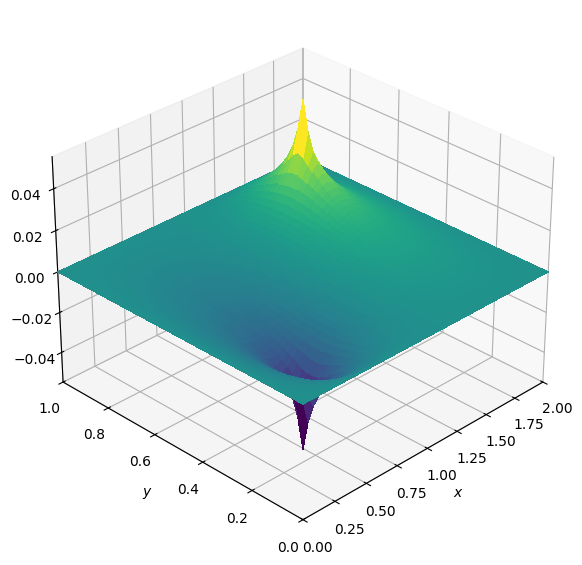

In [6]:
#NBVAL_IGNORE_OUTPUT
plot_field(p.data, xmax=xmax, ymax=ymax, view=(30, 225))